In [5]:
import galstreams
mws = galstreams.MWStreams(verbose=False)

import sys, pickle, os
from importlib import reload
from tqdm import tqdm, trange

import numpy as np, pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm, LogNorm

import agama 
Gyr_to_AgamaTime = 1.0227 # 1 Gyr in Agama time units (kpc/(km/s))
import nbody_streams.agama_helper as ah

import emcee
#import corner

from astropy import units as u
import astropy.coordinates as coord
from astropy.coordinates import Galactocentric, ICRS, CartesianDifferential, CartesianRepresentation
from astropy import table

Initializing galstreams library from master_log... 


In [3]:
sys.path.append('../scripts/')
from coordinate_utils import get_rotation_matrix, sf_to_icrs, icrs_to_sf
from generate_sim_stream import create_stream_particle_spray
from stream_likelihood import log_likelihood, make_spline, log_prior, log_probability
from stream_data_utils import read_in_data

In [4]:
aau_member_path = '../data/aau_members.csv'
aau_distance_path = '../data/aau_bhb_rrl.csv'

aau_table = pd.read_csv(aau_member_path)
aau_bhb_rrl_data = pd.read_csv(aau_distance_path)

aau_bhb_rrl_data.columns = aau_bhb_rrl_data.columns.str.lower()

df_aau, prog_pars_aau, prog_pars_icrs_aau, df_distance_aau = read_in_data(aau_table, 'distance_modulus', aau_bhb_rrl_data)

prog_pars_aau[2] = 10**(((prog_pars_aau[2]) + 5) / 5) / 1000.0
prog_pars_icrs_aau[2] = 10**(((prog_pars_icrs_aau[2]) + 5) / 5) / 1000.0 

jet_member_path = '../data/jet_members.csv'

jet_table = pd.read_csv(jet_member_path)

df_jet, distance_fit_jet, prog_pars_jet, prog_pars_icrs_jet = read_in_data(jet_table, 'bhb_dist')

In [4]:
#Constructing a data dictionary given stream data_frame
data_dict_aau = dict(
    phi1_obs = df_aau['phi1'].values,
    phi1_obs_dist = df_distance_aau['phi1'].values,
    phi2_obs = df_aau['phi2'].values,
    rv_obs = df_aau['vel_calib'].values,
    rv_obs_errors = df_aau['vel_calib_std'].values,
    dist_obs = 10**(((df_distance_aau['distance_modulus'].values) + 5) / 5) / 1000.0,
    dist_obs_errors = ((10**(((df_distance_aau['distance_modulus'].values) + 5) / 5) / 1000.0)*0.1),
    pmra_cosdec_obs = df_aau['pmra'].values,
    pmra_cosdec_obs_errors = df_aau['pmra_error'].values,
    pmdec_obs = df_aau['pmdec'].values,
    pmdec_obs_errors = df_aau['pmdec_error'].values,
)

data_dict_jet = dict(
    phi1_obs = df_jet['phi1'].values,
    phi2_obs = df_jet['phi2'].values,
    rv_obs = df_jet['vel_calib'].values,
    rv_obs_errors = df_jet['vel_calib_std'].values,
    dist_obs = df_jet['bhb_dist'].values,
    dist_obs_errors = (df_jet['bhb_dist'].values*0.1),
    pmra_cosdec_obs = df_jet['pmra'].values,
    pmra_cosdec_obs_errors = df_jet['pmra_error'].values,
    pmdec_obs = df_jet['pmdec'].values,
    pmdec_obs_errors = df_jet['pmdec_error'].values,
)

In [5]:
BASE_POT_PATH = '../potential_files/'
potMW_path = os.path.join(BASE_POT_PATH, 'base_mw_pot.ini')
## potential models to load
basePot = agama.Potential(file=potMW_path)
scale_1 = agama.Potential(type = 'NFW', mass = 5.5427e11, scaleRadius = 15.626, scale= [[-5, 0.1, 1],[0, 1, 1]])
scale_2 = agama.Potential(type = 'NFW', mass = 5.5427e11, scaleRadius = 15.626, scale= [[-5, 0.2, 1],[0, 1, 1]])
scale_3 = agama.Potential(type = 'NFW', mass = 5.5427e11, scaleRadius = 15.626, scale= [[-5, 0.3, 1],[0, 1, 1]])
scale_4 = agama.Potential(type = 'NFW', mass = 5.5427e11, scaleRadius = 15.626, scale= [[-5, 0.4, 1],[0, 1, 1]])
scale_5 = agama.Potential(type = 'NFW', mass = 5.5427e11, scaleRadius = 15.626, scale= [[-5, 0.5, 1],[0, 1, 1]])
scale_6 = agama.Potential(type = 'NFW', mass = 5.5427e11, scaleRadius = 15.626, scale= [[-5, 0.6, 1],[0, 1, 1]])
scale_7 = agama.Potential(type = 'NFW', mass = 5.5427e11, scaleRadius = 15.626, scale= [[-5, 0.7, 1],[0, 1, 1]])
scale_8 = agama.Potential(type='NFW', mass=5.5427e11, scaleRadius=15.626, scale=[[-5, 0.8, 1],[0, 1, 1]])
scale_9 = agama.Potential(type='NFW', mass=5.5427e11, scaleRadius=15.626, scale=[[-5, 0.9, 1],[0, 1, 1]])
scale_10 = agama.Potential(type='NFW', mass=5.5427e11, scaleRadius=15.626, scale=[[-5, 1.0, 1],[0, 1, 1]])

pot_1= basePot + scale_1
pot_2 = basePot + scale_2
pot_3 = basePot + scale_3
pot_4 = basePot + scale_4
pot_5 = basePot + scale_5
pot_6 = basePot + scale_6
pot_7 = basePot + scale_7
pot_8 = basePot + scale_8
pot_9 = basePot + scale_9
pot_10 = basePot + scale_10

NFW = agama.Potential(type= 'NFW', mass = 5.5427e11, scaleRadius = 15.626)

potStat = basePot + NFW
#pot_spheroid.density([10, 0, 0], t=0), pot_spheroid.density([10, 0, 0], t=-5)
#pot_spheroid = agama.Potential(type='spheroid', mass=1e12, scaleradius=20, scale=[[-5, 0.5, 1],[0, 1, 1]])

In [6]:
'''
This notebook maps the percent change of the peri and apo centers of streams -5.0 Gyr to present day in linearly scaled potentials. 

Two graphs being made here: mapping the percent change 
'''

'\nThis notebook maps the percent change of the peri and apo centers of streams -5.0 Gyr to present day in linearly scaled potentials. \n\nTwo graphs being made here: mapping the percent change \n'

In [7]:
#Constructing stream progenitor present-day coordinates and information

prog_mass, prog_scaleradius =  20_000, 10/1_000 # Msun, kpc

num_particles = 3_000

Age_stream_inGyr = 5.0

R = np.array([[-0.69533693,  0.61240175, -0.37612584],
                    [-0.62909984, -0.26561497,  0.73053548],
                 [ 0.34747655,  0.744589,    0.56995374]])

jet_rot_matrix = u.Quantity(R, unit=u.dimensionless_unscaled)

#jet_rot_matrix = get_rotation_matrix('Jet-F22', mws = mws)
#print(jet_rot_matrix)

static_pot_bestfit_6D = [0, 0.15, 30.08, -0.64, -1.46, 272.41]

icrs_coord_ra, icrs_coord_dec = sf_to_icrs(static_pot_bestfit_6D[0], static_pot_bestfit_6D[1], jet_rot_matrix)
print(icrs_coord_ra, type(icrs_coord_ra))
print(icrs_coord_dec, type(icrs_coord_dec))

dist, pmra, pmdec, rv = static_pot_bestfit_6D[-4:]

jet_c = coord.SkyCoord(
        ra=icrs_coord_ra*u.degree, dec=icrs_coord_dec*u.degree, distance=dist*u.kpc, 
        pm_ra_cosdec=pmra*u.mas/u.yr,
        pm_dec=pmdec*u.mas/u.yr,
        radial_velocity=rv*u.km/u.s
    )
    
rep = jet_c.transform_to(coord.Galactocentric) # units here are kpc, km/s
    
prog_wtoday_gal = np.array(
        [rep.x.value, rep.y.value, rep.z.value,
         rep.v_x.value, rep.v_y.value, rep.v_z.value])

print(prog_wtoday_gal)

138.50121429303636 <class 'numpy.ndarray'>
-22.00159581100559 <class 'numpy.ndarray'>
[ -17.64031256  -26.95909359    9.37039313   -1.49156767  -91.40702591
 -102.2028583 ]


In [8]:
stream_model_1 = create_stream_particle_spray(
    pot_host=pot_1, 
    initmass=prog_mass, 
    scaleradius=prog_scaleradius, 
    prog_pot_kind='Plummer', 
    sat_cen_present=prog_wtoday_gal, 
    num_particles=num_particles,
    time_end=0.0, 
    time_total=Age_stream_inGyr, save_rate=1000,
    #add_perturber={'mass':0},
)
stream_model_2 = create_stream_particle_spray(
    pot_host=pot_2,
    initmass=prog_mass,
    scaleradius=prog_scaleradius,
    prog_pot_kind='Plummer',
    sat_cen_present=prog_wtoday_gal,
    num_particles=num_particles,
    time_end=0.0,
    time_total=Age_stream_inGyr, save_rate=1000,
)
stream_model_3 = create_stream_particle_spray(
    pot_host=pot_3,
    initmass=prog_mass,
    scaleradius=prog_scaleradius,
    prog_pot_kind='Plummer',
    sat_cen_present=prog_wtoday_gal,
    num_particles=num_particles,
    time_end=0.0,
    time_total=Age_stream_inGyr, save_rate=1000,
)
stream_model_4 = create_stream_particle_spray(
    pot_host=pot_4,
    initmass=prog_mass,
    scaleradius=prog_scaleradius,
    prog_pot_kind='Plummer',
    sat_cen_present=prog_wtoday_gal,
    num_particles=num_particles,
    time_end=0.0,
    time_total=Age_stream_inGyr, save_rate=1000,
)
stream_model_5 = create_stream_particle_spray(
    pot_host=pot_5,
    initmass=prog_mass,
    scaleradius=prog_scaleradius,
    prog_pot_kind='Plummer',
    sat_cen_present=prog_wtoday_gal,
    num_particles=num_particles,
    time_end=0.0,
    time_total=Age_stream_inGyr, save_rate=1000,
)
stream_model_6 = create_stream_particle_spray(
    pot_host=pot_6,
    initmass=prog_mass,
    scaleradius=prog_scaleradius,
    prog_pot_kind='Plummer',
    sat_cen_present=prog_wtoday_gal,
    num_particles=num_particles,
    time_end=0.0,
    time_total=Age_stream_inGyr, save_rate=1000,
)
stream_model_7 = create_stream_particle_spray(
    pot_host=pot_7,
    initmass=prog_mass,
    scaleradius=prog_scaleradius,
    prog_pot_kind='Plummer',
    sat_cen_present=prog_wtoday_gal,
    num_particles=num_particles,
    time_end=0.0,
    time_total=Age_stream_inGyr, save_rate=1000,
)

stream_model_8 = create_stream_particle_spray(
    pot_host=pot_8,
    initmass=prog_mass,
    scaleradius=prog_scaleradius,
    prog_pot_kind='Plummer',
    sat_cen_present=prog_wtoday_gal,
    num_particles=num_particles,
    time_end=0.0,
    time_total=Age_stream_inGyr, save_rate=1000,
)
stream_model_9 = create_stream_particle_spray(
    pot_host=pot_9,
    initmass=prog_mass,
    scaleradius=prog_scaleradius,
    prog_pot_kind='Plummer',
    sat_cen_present=prog_wtoday_gal,
    num_particles=num_particles,
    time_end=0.0,
    time_total=Age_stream_inGyr, save_rate=1000,
)
stream_model_10 = create_stream_particle_spray(
    pot_host=pot_10,
    initmass=prog_mass,
    scaleradius=prog_scaleradius,
    prog_pot_kind='Plummer',
    sat_cen_present=prog_wtoday_gal,
    num_particles=num_particles,
    time_end=0.0,
    time_total=Age_stream_inGyr, save_rate=1000,
)

stream_model_stat = create_stream_particle_spray(
    pot_host=potStat, 
    initmass=prog_mass, 
    scaleradius=prog_scaleradius, 
    prog_pot_kind='Plummer', 
    sat_cen_present=prog_wtoday_gal, 
    num_particles=num_particles,
    time_end=0.0, 
    time_total=Age_stream_inGyr, save_rate=1000,
    #add_perturber={'mass':0},
)

In [9]:
stream_model_1.keys()

dict_keys(['times', 'prog_xv', 'part_xv'])

In [10]:
stream_model_1['prog_xv'].shape

(1000, 6)

In [11]:
times_1 = stream_model_1['times']
r_1 = np.sqrt(stream_model_1['prog_xv'][:,0]**2 + stream_model_1['prog_xv'][:,1]**2 + stream_model_1['prog_xv'][:,2]**2)
dr_1 = np.diff(r_1)
peri_idx_1 = np.where((dr_1[:-1] < 0) & (dr_1[1:] > 0))[0] + 1
apo_idx_1  = np.where((dr_1[:-1] > 0) & (dr_1[1:] < 0))[0] + 1
pericenters_1 = r_1[peri_idx_1]
apocenters_1  = r_1[apo_idx_1]
peri_times_1  = times_1[peri_idx_1]
apo_times_1   = times_1[apo_idx_1]

times_2 = stream_model_2['times']
r_2 = np.sqrt(stream_model_2['prog_xv'][:,0]**2 + stream_model_2['prog_xv'][:,1]**2 + stream_model_2['prog_xv'][:,2]**2)
dr_2 = np.diff(r_2)
peri_idx_2 = np.where((dr_2[:-1] < 0) & (dr_2[1:] > 0))[0] + 1
apo_idx_2  = np.where((dr_2[:-1] > 0) & (dr_2[1:] < 0))[0] + 1
pericenters_2 = r_2[peri_idx_2]
apocenters_2  = r_2[apo_idx_2]
peri_times_2  = times_2[peri_idx_2]
apo_times_2   = times_2[apo_idx_2]

times_3 = stream_model_3['times']
r_3 = np.sqrt(stream_model_3['prog_xv'][:,0]**2 + stream_model_3['prog_xv'][:,1]**2 + stream_model_3['prog_xv'][:,2]**2)
dr_3 = np.diff(r_3)
peri_idx_3 = np.where((dr_3[:-1] < 0) & (dr_3[1:] > 0))[0] + 1
apo_idx_3  = np.where((dr_3[:-1] > 0) & (dr_3[1:] < 0))[0] + 1
pericenters_3 = r_3[peri_idx_3]
apocenters_3  = r_3[apo_idx_3]
peri_times_3  = times_3[peri_idx_3]
apo_times_3   = times_3[apo_idx_3]

times_4 = stream_model_4['times']
r_4 = np.sqrt(stream_model_4['prog_xv'][:,0]**2 + stream_model_4['prog_xv'][:,1]**2 + stream_model_4['prog_xv'][:,2]**2)
dr_4 = np.diff(r_4)
peri_idx_4 = np.where((dr_4[:-1] < 0) & (dr_4[1:] > 0))[0] + 1
apo_idx_4  = np.where((dr_4[:-1] > 0) & (dr_4[1:] < 0))[0] + 1
pericenters_4 = r_4[peri_idx_4]
apocenters_4  = r_4[apo_idx_4]
peri_times_4  = times_4[peri_idx_4]
apo_times_4   = times_4[apo_idx_4]

times_5 = stream_model_5['times']
r_5 = np.sqrt(stream_model_5['prog_xv'][:,0]**2 + stream_model_5['prog_xv'][:,1]**2 + stream_model_5['prog_xv'][:,2]**2)
dr_5 = np.diff(r_5)
peri_idx_5 = np.where((dr_5[:-1] < 0) & (dr_5[1:] > 0))[0] + 1
apo_idx_5  = np.where((dr_5[:-1] > 0) & (dr_5[1:] < 0))[0] + 1
pericenters_5 = r_5[peri_idx_5]
apocenters_5  = r_5[apo_idx_5]
peri_times_5  = times_5[peri_idx_5]
apo_times_5   = times_5[apo_idx_5]

times_6 = stream_model_6['times']
r_6 = np.sqrt(stream_model_6['prog_xv'][:,0]**2 + stream_model_6['prog_xv'][:,1]**2 + stream_model_6['prog_xv'][:,2]**2)
dr_6 = np.diff(r_6)
peri_idx_6 = np.where((dr_6[:-1] < 0) & (dr_6[1:] > 0))[0] + 1
apo_idx_6  = np.where((dr_6[:-1] > 0) & (dr_6[1:] < 0))[0] + 1
pericenters_6 = r_6[peri_idx_6]
apocenters_6  = r_6[apo_idx_6]
peri_times_6  = times_6[peri_idx_6]
apo_times_6   = times_6[apo_idx_6]

times_7 = stream_model_7['times']
r_7 = np.sqrt(stream_model_7['prog_xv'][:,0]**2 + stream_model_7['prog_xv'][:,1]**2 + stream_model_7['prog_xv'][:,2]**2)
dr_7 = np.diff(r_7)
peri_idx_7 = np.where((dr_7[:-1] < 0) & (dr_7[1:] > 0))[0] + 1
apo_idx_7  = np.where((dr_7[:-1] > 0) & (dr_7[1:] < 0))[0] + 1
pericenters_7 = r_7[peri_idx_7]
apocenters_7  = r_7[apo_idx_7]
peri_times_7  = times_7[peri_idx_7]
apo_times_7   = times_7[apo_idx_7]

times_8 = stream_model_8['times']
r_8 = np.sqrt(stream_model_8['prog_xv'][:,0]**2 + stream_model_8['prog_xv'][:,1]**2 + stream_model_8['prog_xv'][:,2]**2)
dr_8 = np.diff(r_8)
peri_idx_8 = np.where((dr_8[:-1] < 0) & (dr_8[1:] > 0))[0] + 1
apo_idx_8  = np.where((dr_8[:-1] > 0) & (dr_8[1:] < 0))[0] + 1
pericenters_8 = r_8[peri_idx_8]
apocenters_8  = r_8[apo_idx_8]
peri_times_8  = times_8[peri_idx_8]
apo_times_8   = times_8[apo_idx_8]

times_9 = stream_model_9['times']
r_9 = np.sqrt(stream_model_9['prog_xv'][:,0]**2 + stream_model_9['prog_xv'][:,1]**2 + stream_model_9['prog_xv'][:,2]**2)
dr_9 = np.diff(r_9)
peri_idx_9 = np.where((dr_9[:-1] < 0) & (dr_9[1:] > 0))[0] + 1
apo_idx_9  = np.where((dr_9[:-1] > 0) & (dr_9[1:] < 0))[0] + 1
pericenters_9 = r_9[peri_idx_9]
apocenters_9  = r_9[apo_idx_9]
peri_times_9  = times_9[peri_idx_9]
apo_times_9   = times_9[apo_idx_9]

times_10 = stream_model_10['times']
r_10 = np.sqrt(stream_model_10['prog_xv'][:,0]**2 + stream_model_10['prog_xv'][:,1]**2 + stream_model_10['prog_xv'][:,2]**2)
dr_10 = np.diff(r_10)
peri_idx_10 = np.where((dr_10[:-1] < 0) & (dr_10[1:] > 0))[0] + 1
apo_idx_10  = np.where((dr_10[:-1] > 0) & (dr_10[1:] < 0))[0] + 1
pericenters_10 = r_10[peri_idx_10]
apocenters_10  = r_10[apo_idx_10]
peri_times_10  = times_10[peri_idx_10]
apo_times_10   = times_10[apo_idx_10]

scale_labels = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

pericenters = [pericenters_1[-1], pericenters_2[-1], pericenters_3[-1], pericenters_4[-1],
               pericenters_5[-1], pericenters_6[-1], pericenters_7[-1], pericenters_8[-1],
               pericenters_9[-1], pericenters_10[-1]]
apocenters  = [apocenters_1[-1], apocenters_2[-1], apocenters_3[-1], apocenters_4[-1],
               apocenters_5[-1], apocenters_6[-1], apocenters_7[-1], apocenters_8[-1],
               apocenters_9[-1], apocenters_10[-1]]
peri_times  = [peri_times_1[-1], peri_times_2[-1], peri_times_3[-1], peri_times_4[-1],
               peri_times_5[-1], peri_times_6[-1], peri_times_7[-1], peri_times_8[-1],
               peri_times_9[-1], peri_times_10[-1]]
apo_times   = [apo_times_1[-1], apo_times_2[-1], apo_times_3[-1], apo_times_4[-1],
               apo_times_5[-1], apo_times_6[-1], apo_times_7[-1], apo_times_8[-1],
               apo_times_9[-1], apo_times_10[-1]]

r_all     = [r_1, r_2, r_3, r_4, r_5, r_6, r_7, r_8, r_9, r_10]
times_all = [times_1, times_2, times_3, times_4, times_5, times_6, times_7, times_8, times_9, times_10]
peri_idx_all = [peri_idx_1, peri_idx_2, peri_idx_3, peri_idx_4, peri_idx_5,
                peri_idx_6, peri_idx_7, peri_idx_8, peri_idx_9, peri_idx_10]
apo_idx_all  = [apo_idx_1,  apo_idx_2,  apo_idx_3,  apo_idx_4,  apo_idx_5,
                apo_idx_6,  apo_idx_7,  apo_idx_8,  apo_idx_9,  apo_idx_10]

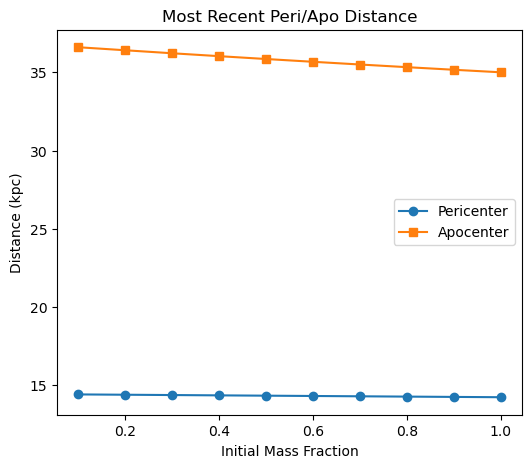

In [12]:
# Plot 1: peri/apo distance vs scale
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(scale_labels, pericenters, 'o-', label='Pericenter')
ax.plot(scale_labels, apocenters,  's-', label='Apocenter')
ax.set_xlabel('Initial Mass Fraction')
ax.set_ylabel('Distance (kpc)')
ax.set_title('Most Recent Peri/Apo Distance')
ax.legend()
plt.show()

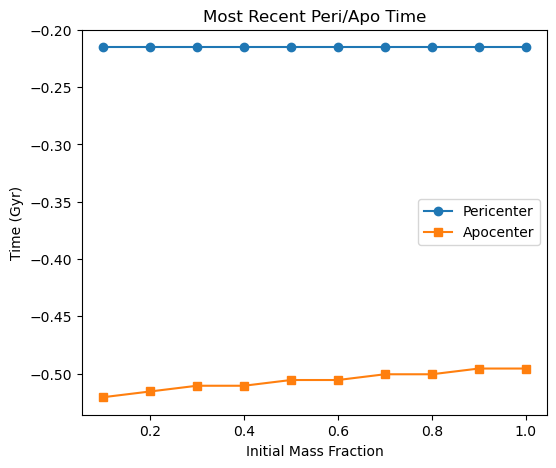

In [13]:
# Plot 2: peri/apo time vs scale
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(scale_labels, peri_times, 'o-', label='Pericenter')
ax.plot(scale_labels, apo_times,  's-', label='Apocenter')
ax.set_xlabel('Initial Mass Fraction')
ax.set_ylabel('Time (Gyr)')
ax.set_title('Most Recent Peri/Apo Time')
ax.legend()
plt.show()

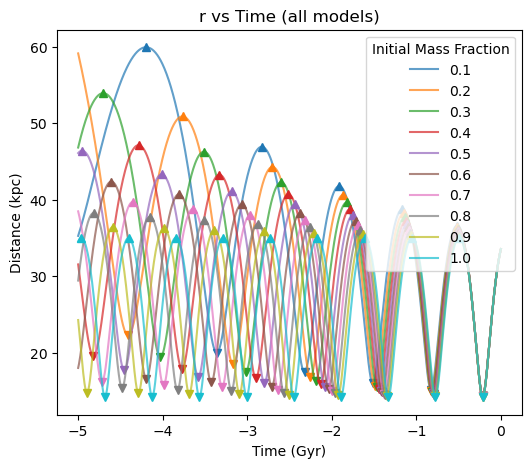

In [14]:
# Plot 3: r vs time for all 10 models
fig, ax = plt.subplots(figsize=(6, 5))
for i, (r, times, peri_idx, apo_idx) in enumerate(zip(r_all, times_all, peri_idx_all, apo_idx_all), 1):
    line, = ax.plot(times, r, alpha=0.7, label=f'{i*0.1:.1f}')
    ax.plot(times[peri_idx], r[peri_idx], 'v', color=line.get_color())
    ax.plot(times[apo_idx],  r[apo_idx],  '^', color=line.get_color())
ax.set_xlabel('Time (Gyr)')
ax.set_ylabel('Distance (kpc)')
ax.set_title('r vs Time (all models)')
ax.legend(title='Initial Mass Fraction')
plt.show()

In [16]:
initial_mass_fractions = np.linspace(0.1, 1.0, 50)
vmax_values = []

for f in initial_mass_fractions:
    mass_enc = pot_model.enclosedMass(radius) * 2 * f
    vcirc = np.sqrt(G * mass_enc / radius)
    imax = np.argmax(vcirc)
    vmax_values.append(vcirc[imax])

plt.plot(initial_mass_fractions, vmax_values)
plt.xlabel("Initial mass fraction")
plt.ylabel("vmax [km/s]")
plt.title("vmax vs initial mass fraction")

NameError: name 'pot_model' is not defined

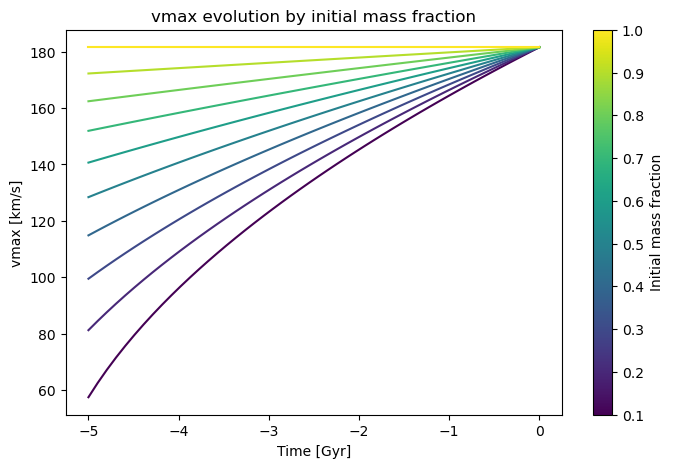

In [19]:
import matplotlib.cm as cm

times = np.linspace(-5, 0, 50)
initial_mass_fractions = np.linspace(0.1, 1.0, 10)

fig, ax = plt.subplots(figsize=(8, 5))
cmap = cm.viridis
norm = plt.Normalize(vmin=0.1, vmax=1.0)

for f in initial_mass_fractions:
    pot = agama.Potential(type='NFW', mass=NFW_mass, scaleRadius=NFW_rs,
                          scale=[[-5, f, 1], [0, 1.0, 1]])
    vmax_values = []
    for t in times:
        scale_m = f + (1.0 - f) * (t + 5) / 5
        mass_enc = pot.enclosedMass(radius) * scale_m
        vcirc = np.sqrt(G * mass_enc / radius)
        vmax_values.append(vcirc[np.argmax(vcirc)])
    
    ax.plot(times, vmax_values, color=cmap(norm(f)))

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, label="Initial mass fraction")
ax.set_xlabel("Time [Gyr]")
ax.set_ylabel("vmax [km/s]")
ax.set_title("vmax evolution by initial mass fraction")
plt.show()

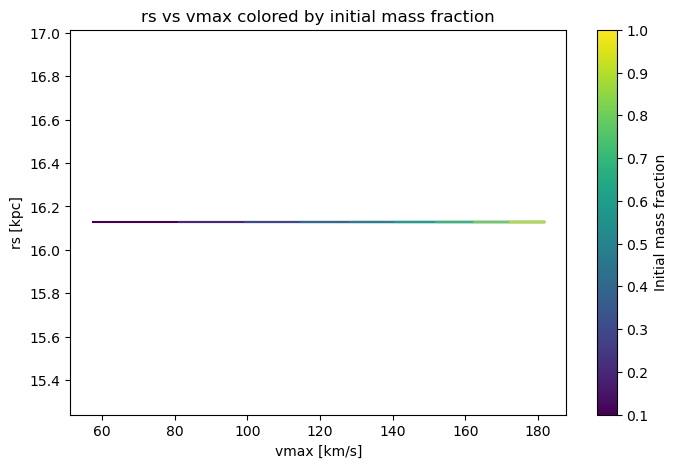

In [20]:
import matplotlib.cm as cm

times = np.linspace(-5, 0, 50)
initial_mass_fractions = np.linspace(0.1, 1.0, 10)

fig, ax = plt.subplots(figsize=(8, 5))
cmap = cm.viridis
norm = plt.Normalize(vmin=0.1, vmax=1.0)

for f in initial_mass_fractions:
    pot = agama.Potential(type='NFW', mass=NFW_mass, scaleRadius=NFW_rs,
                          scale=[[-5, f, 1], [0, 1.0, 1]])
    rs_values = []
    vmax_values = []
    for t in times:
        scale_m = f + (1.0 - f) * (t + 5) / 5
        mass_enc = pot.enclosedMass(radius) * scale_m
        vcirc = np.sqrt(G * mass_enc / radius)
        imax = np.argmax(vcirc)
        rs_values.append(radius[imax] / 2.163)
        vmax_values.append(vcirc[imax])
    
    ax.plot(vmax_values, rs_values, color=cmap(norm(f)))

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, label="Initial mass fraction")
ax.set_xlabel("vmax [km/s]")
ax.set_ylabel("rs [kpc]")
ax.set_title("rs vs vmax colored by initial mass fraction")
plt.show()

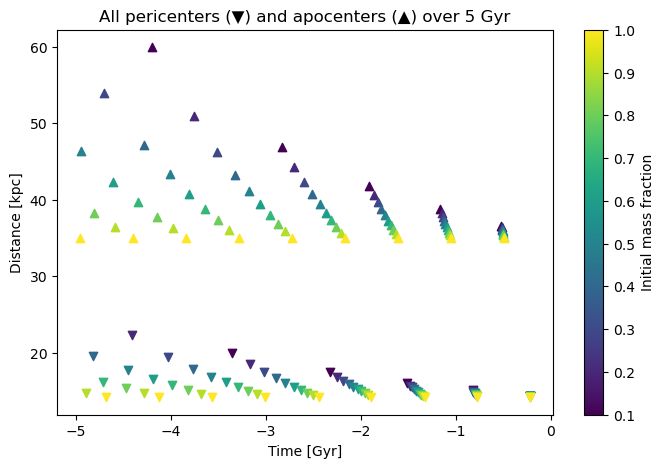

In [21]:
import matplotlib.cm as cm

all_pericenters = [pericenters_1, pericenters_2, pericenters_3, pericenters_4, pericenters_5,
                   pericenters_6, pericenters_7, pericenters_8, pericenters_9, pericenters_10]
all_apocenters  = [apocenters_1,  apocenters_2,  apocenters_3,  apocenters_4,  apocenters_5,
                   apocenters_6,  apocenters_7,  apocenters_8,  apocenters_9,  apocenters_10]
all_peri_times  = [peri_times_1, peri_times_2, peri_times_3, peri_times_4, peri_times_5,
                   peri_times_6, peri_times_7, peri_times_8, peri_times_9, peri_times_10]
all_apo_times   = [apo_times_1,  apo_times_2,  apo_times_3,  apo_times_4,  apo_times_5,
                   apo_times_6,  apo_times_7,  apo_times_8,  apo_times_9,  apo_times_10]

cmap = cm.viridis
norm = plt.Normalize(vmin=0.1, vmax=1.0)

fig, ax = plt.subplots(figsize=(8, 5))
for i, (pt, p, at, a) in enumerate(zip(all_peri_times, all_pericenters, all_apo_times, all_apocenters)):
    f = scale_labels[i]
    color = cmap(norm(f))
    ax.scatter(pt, p, marker='v', color=color, label=f if i == 0 else '')
    ax.scatter(at, a, marker='^', color=color)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, label='Initial mass fraction')
ax.set_xlabel('Time [Gyr]')
ax.set_ylabel('Distance [kpc]')
ax.set_title('All pericenters (▼) and apocenters (▲) over 5 Gyr')
plt.show()

In [22]:
for i, (pt, at) in enumerate(zip(all_peri_times, all_apo_times)):
    f = scale_labels[i]
    print(f"f={f:.1f}  |  n_peri={len(pt)}  |  n_apo={len(at)}")

f=0.1  |  n_peri=5  |  n_apo=5
f=0.2  |  n_peri=6  |  n_apo=5
f=0.3  |  n_peri=6  |  n_apo=6
f=0.4  |  n_peri=7  |  n_apo=6
f=0.5  |  n_peri=7  |  n_apo=7
f=0.6  |  n_peri=7  |  n_apo=7
f=0.7  |  n_peri=8  |  n_apo=7
f=0.8  |  n_peri=8  |  n_apo=8
f=0.9  |  n_peri=9  |  n_apo=8
f=1.0  |  n_peri=9  |  n_apo=9


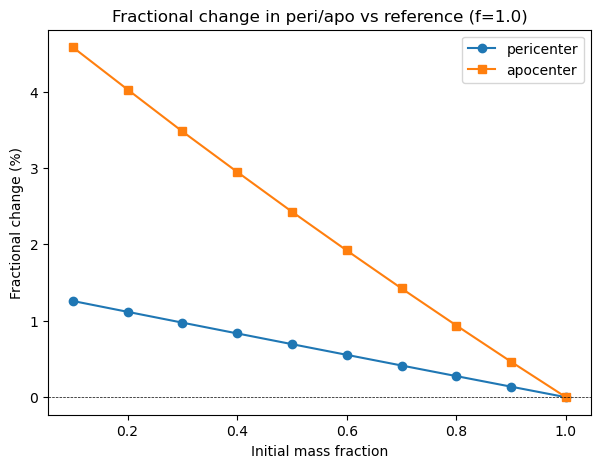

In [23]:
# use scale_10 (f=1.0) as the reference
ref_peri = pericenters_10[-1]
ref_apo  = apocenters_10[-1]

frac_peri = [(p - ref_peri) / ref_peri * 100 for p in pericenters]
frac_apo  = [(a - ref_apo)  / ref_apo  * 100 for a in apocenters]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(scale_labels, frac_peri, 'o-', label='pericenter')
ax.plot(scale_labels, frac_apo,  's-', label='apocenter')
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_xlabel('Initial mass fraction')
ax.set_ylabel('Fractional change (%)')
ax.set_title('Fractional change in peri/apo vs reference (f=1.0)')
ax.legend()
plt.show()

In [26]:
#two ago/three ago peri and apo

In [ ]:
#add in lmc and look aau progenitor and jet progenitor

In [27]:
agama.Potential?

Init signature: agama.Potential(self, /, *args, **kwargs)
Docstring:     
Potential is a class that represents a wide range of gravitational potentials.
There are several ways of initializing the potential instance:
  - from a list of key=value arguments that specify an elementary potential class;
  - from a tuple of dictionary objects that contain the same list of possible key/value pairs for each component of a composite potential;
  - from an INI file with these parameters for one or several components and/or with potential expansion coefficients previously stored by the export() method;
  - from a tuple of existing Potential objects created previously (in this case a composite potential is created from these components).
Note that all keywords and their values are not case-sensitive.

List of possible keywords for a single component:
  type='...'   the type of potential, can be one of the following 'basic' types:
    Harmonic, Logarithmic, Plummer, MiyamotoNagai, NFW, Ferrers, Dehn

In [6]:
mws

{'20.0-1-M18': <galstreams.core.Track6D at 0x7f32f1112390>,
 '300S-F18': <galstreams.core.Track6D at 0x7f32f3453f50>,
 'AAU-ATLAS-L21': <galstreams.core.Track6D at 0x7f32f4809e80>,
 'AAU-AliqaUma-L21': <galstreams.core.Track6D at 0x7f32f4433410>,
 'ACS-R21': <galstreams.core.Track6D at 0x7f32f11bb8c0>,
 'Acheron-G09': <galstreams.core.Track6D at 0x7f32f3453230>,
 'Alpheus-G13': <galstreams.core.Track6D at 0x7f32f1154500>,
 'Aquarius-W11': <galstreams.core.Track6D at 0x7f32f1142660>,
 'C-10-I24': <galstreams.core.Track6D at 0x7f32f11aee40>,
 'C-11-I24': <galstreams.core.Track6D at 0x7f32f11ba810>,
 'C-12-I24': <galstreams.core.Track6D at 0x7f32f11ac470>,
 'C-13-I24': <galstreams.core.Track6D at 0x7f32f11562d0>,
 'C-19-I21': <galstreams.core.Track6D at 0x7f32f11e71a0>,
 'C-20-I24': <galstreams.core.Track6D at 0x7f32f0d62b10>,
 'C-22-I24': <galstreams.core.Track6D at 0x7f32f1165d90>,
 'C-23-I24': <galstreams.core.Track6D at 0x7f32f11ad8b0>,
 'C-24-I24': <galstreams.core.Track6D at 0x7f32f

In [9]:
tuc_3_rot_matrix = get_rotation_matrix('TucanaIII-S19', mws = mws)
print(tuc_3_rot_matrix)

[[ 0.50571323 -0.00746053 -0.86266938]
 [ 0.07865209  0.99619687  0.03749205]
 [ 0.85910883 -0.08681098  0.50437672]]
